# TABR event inference

Notebook ini merangkum inference event-level untuk TABR dari frame-level probability.

Fokus pembacaan akhir:
- kandidat rule 1: `top3_mean >= 0.70`
- kandidat rule 2: `max >= 0.90`

Tujuan notebook: menyiapkan hasil yang rapi agar dua rule ini bisa dibandingkan dengan mudah.


In [1]:
from __future__ import annotations

import json
import os
import re
import sys
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from scipy.special import expit

sns.set_theme(style='whitegrid')
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

TABR_ROOT = ROOT / 'third_party' / 'tabular-dl-tabr-official'
os.environ['PROJECT_DIR'] = str(TABR_ROOT)
if str(TABR_ROOT) not in sys.path:
    sys.path.append(str(TABR_ROOT))

import lib
from bin.tabr import Model
from comparasion.core.config import ComparisonConfig
from comparasion.core.roi import ROIExtractor
from features_extraction.poc import POC
from features_extraction.quadran import Quadran
from features_extraction.vektor import Vektor

MODEL_DIR = ROOT / 'third_party' / 'tabular-dl-tabr-official' / 'exp' / 'tabr' / 'convat_apex_anxiety' / '0-evaluation' / '11'
DATA_DIR = ROOT / 'third_party' / 'tabular-dl-tabr-official' / 'data' / 'convat_apex_anxiety'
MODEL_CONFIG = lib.load_config(MODEL_DIR.parent / '11.toml')
FEATURE_COLS = json.loads((DATA_DIR / 'feature_cols.json').read_text())
FINAL_THRESHOLD = 0.5
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

dataset = lib.build_dataset(**MODEL_CONFIG['data']).to_torch(device)
model = Model(
    n_num_features=dataset.n_num_features,
    n_bin_features=dataset.n_bin_features,
    cat_cardinalities=dataset.cat_cardinalities(),
    n_classes=dataset.n_classes(),
    **MODEL_CONFIG['model'],
).to(device)
checkpoint = lib.load_checkpoint(MODEL_DIR)
model.load_state_dict(checkpoint['model'])
model.eval()

def get_Xy(part: str, idx=None):
    batch = (
        {key[2:]: dataset.data[key][part] for key in dataset.data if key.startswith('X_')},
        dataset.Y[part],
    )
    if idx is None:
        return batch
    return ({k: v[idx] for k, v in batch[0].items()}, batch[1][idx])

candidate_x, candidate_y = get_Xy('train', None)

REGIONS = {
    'mulut': list(range(48, 68)),
    'mata_kiri': list(range(17, 22)) + list(range(36, 42)),
    'mata_kanan': list(range(22, 27)) + list(range(42, 48)),
}
TARGET_SIZE = {
    'mulut': (70, 35),
    'mata_kiri': (48, 32),
    'mata_kanan': (48, 32),
}
cmp_config = ComparisonConfig(
    predictor_path=ROOT / 'preprocess-anxiety' / 'models' / 'shape_predictor_68_face_landmarks.dat',
    output_root=Path('output/apex/tmp_compare'),
    regions=REGIONS,
    target_size=TARGET_SIZE,
)
extractor = ROIExtractor(cmp_config)

print('model ready:', MODEL_DIR)
print('feature dim:', len(FEATURE_COLS))
print('threshold:', FINAL_THRESHOLD)
print('device:', device)


2026-04-06 15:12:44.462 | INFO     | lib.data:build_dataset:338 - Using cached dataset: build_dataset__convat_apex_anxiety__None__None__None__None__72__d10c1508d8934c1de65e6394f780722e.pickle


model ready: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/third_party/tabular-dl-tabr-official/exp/tabr/convat_apex_anxiety/0-evaluation/11
feature dim: 392
threshold: 0.5
device: cuda


In [2]:
EVENT_AGGREGATION_METHOD = 'top3_mean'  # default exploratory rule
TOP_K = 3

def aggregate_event_probs(pred_df: pd.DataFrame, method: str = EVENT_AGGREGATION_METHOD, top_k: int = TOP_K) -> float:
    probs = pred_df['prob_anxiety_tinggi'].to_numpy(dtype=float)
    if len(probs) == 0:
        raise ValueError('Empty probability list')
    if method == 'mean':
        return float(np.mean(probs))
    if method == 'max':
        return float(np.max(probs))
    if method == 'median':
        return float(np.median(probs))
    if method == 'top3_mean':
        k = min(top_k, len(probs))
        return float(np.mean(np.sort(probs)[-k:]))
    raise ValueError(f'Unknown aggregation method: {method}')

def get_event_metadata(event_dir: Path) -> dict:
    parts = event_dir.parts
    true_group = 'anxiety' if 'anxiety' in parts else 'tidak' if 'tidak' in parts else None
    participant = None
    for idx, part in enumerate(parts):
        if part in {'anxiety', 'tidak'} and idx + 1 < len(parts):
            participant = parts[idx + 1]
            break
    return {'true_group': true_group, 'participant': participant}

def natural_sort_key(value: str):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', value)]

def to_gray(image: np.ndarray) -> np.ndarray:
    return image if image.ndim == 2 else cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def load_event_frames(event_dir: Path) -> tuple[list[np.ndarray], list[Path]]:
    frame_paths = sorted(
        [p for p in event_dir.iterdir() if p.is_file() and p.suffix.lower() in {'.jpg', '.jpeg', '.png'}],
        key=lambda p: natural_sort_key(p.name),
    )
    if len(frame_paths) < 2:
        raise ValueError(f'Need >= 2 frames: {event_dir}')
    frames = []
    for path in frame_paths:
        image = cv2.imread(str(path))
        if image is None:
            raise FileNotFoundError(f'Failed to read image: {path}')
        frames.append(image)
    return frames, frame_paths

def extract_event_feature_rows(event_dir: Path) -> pd.DataFrame:
    frames, frame_paths = load_event_frames(event_dir)
    baseline_rois = extractor.extract_rois(frames[0])
    baseline_gray = {name: to_gray(img) for name, img in baseline_rois.items()}

    rows = []
    for idx in range(1, len(frames)):
        rois = extractor.extract_rois(frames[idx])
        row = {'frame_path': str(frame_paths[idx].relative_to(ROOT)), 'frame_idx_in_event': idx}
        for comp in cmp_config.regions:
            gray = to_gray(rois[comp])
            poc = POC(baseline_gray[comp], gray, cmp_config.block_size)
            vec = Vektor(poc.getPOC(), cmp_config.block_size)
            quad = Quadran(vec.getVektor()).getQuadran()
            for block_id, block in enumerate(quad, start=1):
                row[f'{comp}_x{block_id}'] = block[1]
                row[f'{comp}_y{block_id}'] = block[2]
                row[f'{comp}_t{block_id}'] = block[3]
                row[f'{comp}_m{block_id}'] = block[4]
        rows.append(row)

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f'No valid feature rows extracted from {event_dir}')
    return pd.concat(
        [
            df[['frame_path', 'frame_idx_in_event']].reset_index(drop=True),
            df[FEATURE_COLS].reset_index(drop=True),
        ],
        axis=1,
    )

@torch.inference_mode()
def predict_feature_df(df_features: pd.DataFrame) -> pd.DataFrame:
    x_np = df_features[FEATURE_COLS].to_numpy(dtype=np.float32)
    x_tensor = torch.as_tensor(x_np, device=device)
    rows = []
    for i in range(len(df_features)):
        x = {'num': x_tensor[i:i+1]}
        logit = model(
            x_=x,
            y=None,
            candidate_x_=candidate_x,
            candidate_y=candidate_y,
            context_size=MODEL_CONFIG['context_size'],
            is_train=False,
        ).squeeze(-1).item()
        prob = float(expit(logit))
        pred = int(prob >= FINAL_THRESHOLD)
        rows.append({
            'frame_idx_in_event': int(df_features.iloc[i]['frame_idx_in_event']),
            'frame_path': df_features.iloc[i]['frame_path'],
            'prob_anxiety_tinggi': prob,
            'pred_label': pred,
            'pred_name': 'anxiety_tinggi' if pred == 1 else 'anxiety_rendah',
        })
    return pd.DataFrame(rows)

def infer_event_dir(event_dir: Path, method: str = EVENT_AGGREGATION_METHOD) -> dict:
    meta = get_event_metadata(event_dir)
    df_features = extract_event_feature_rows(event_dir)
    pred_df = predict_feature_df(df_features)
    agg_prob = aggregate_event_probs(pred_df, method=method)
    agg_pred = int(agg_prob >= FINAL_THRESHOLD)
    return {
        'event_dir': str(event_dir.relative_to(ROOT)),
        'participant': meta['participant'],
        'true_group': meta['true_group'],
        'n_feature_rows': len(df_features),
        'aggregation': method,
        'agg_prob_anxiety_tinggi': agg_prob,
        'threshold': FINAL_THRESHOLD,
        'final_pred_label': agg_pred,
        'final_pred_name': 'anxiety_tinggi' if agg_pred == 1 else 'anxiety_rendah',
        'is_directionally_correct': (
            (meta['true_group'] == 'anxiety' and agg_pred == 1)
            or (meta['true_group'] == 'tidak' and agg_pred == 0)
        ) if meta['true_group'] is not None else None,
    }

def pick_distinct_participant_events(group_name: str, n: int = 5) -> list[Path]:
    root = ROOT / 'output' / 'apex' / 'dataset'
    all_dirs = sorted([p for p in root.rglob('event_*') if p.is_dir() and group_name in p.parts])
    chosen = []
    used_participants = set()
    for p in all_dirs:
        participant = get_event_metadata(p)['participant']
        if participant is None or participant in used_participants:
            continue
        used_participants.add(participant)
        chosen.append(p)
        if len(chosen) >= n:
            break
    return chosen


## Single-event walkthrough


In [3]:
EVENT_DIR = ROOT / 'output' / 'apex' / 'dataset' / 'after' / 'tidak' / 'abdul_aziz_1765187125263' / 'q3' / 'answer_3_ce8ef7e8-63e6-46c1-a510-1b8269c27ce7_sec' / 'event_00131-00143'
EVENT_DIR


PosixPath('/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/dataset/after/tidak/abdul_aziz_1765187125263/q3/answer_3_ce8ef7e8-63e6-46c1-a510-1b8269c27ce7_sec/event_00131-00143')

In [4]:
df_features = extract_event_feature_rows(EVENT_DIR)
pred_df = predict_feature_df(df_features)
display(df_features[['frame_idx_in_event', 'frame_path'] + FEATURE_COLS[:8]].head())
display(pred_df.head())
pred_df[['prob_anxiety_tinggi']].describe()


,frame_idx_in_event,frame_path,mulut_x1,mulut_y1,mulut_t1,mulut_m1,mulut_x2,mulut_y2,mulut_t2,mulut_m2
0,1,output/apex/dataset/after/tidak/abdul_aziz_176...,0,-2,270.0,2.000,0,0,0.0,0.0
1,2,output/apex/dataset/after/tidak/abdul_aziz_176...,0,2,90.0,2.000,0,-2,270.0,2.0
2,3,output/apex/dataset/after/tidak/abdul_aziz_176...,0,-2,270.0,2.000,0,0,0.0,0.0
3,4,output/apex/dataset/after/tidak/abdul_aziz_176...,0,-1,270.0,1.000,0,0,0.0,0.0
4,5,output/apex/dataset/after/tidak/abdul_aziz_176...,1,-1,315.0,1.414,0,0,0.0,0.0


,frame_idx_in_event,frame_path,prob_anxiety_tinggi,pred_label,pred_name
0,1,output/apex/dataset/after/tidak/abdul_aziz_176...,0.126262,0,anxiety_rendah
1,2,output/apex/dataset/after/tidak/abdul_aziz_176...,0.210415,0,anxiety_rendah
2,3,output/apex/dataset/after/tidak/abdul_aziz_176...,0.037067,0,anxiety_rendah
3,4,output/apex/dataset/after/tidak/abdul_aziz_176...,0.009870,0,anxiety_rendah
4,5,output/apex/dataset/after/tidak/abdul_aziz_176...,0.051236,0,anxiety_rendah


,prob_anxiety_tinggi
count,12.000000
mean,0.131548
std,0.190401
min,0.005663
25%,0.034446
50%,0.051770
75%,0.147300
max,0.670057


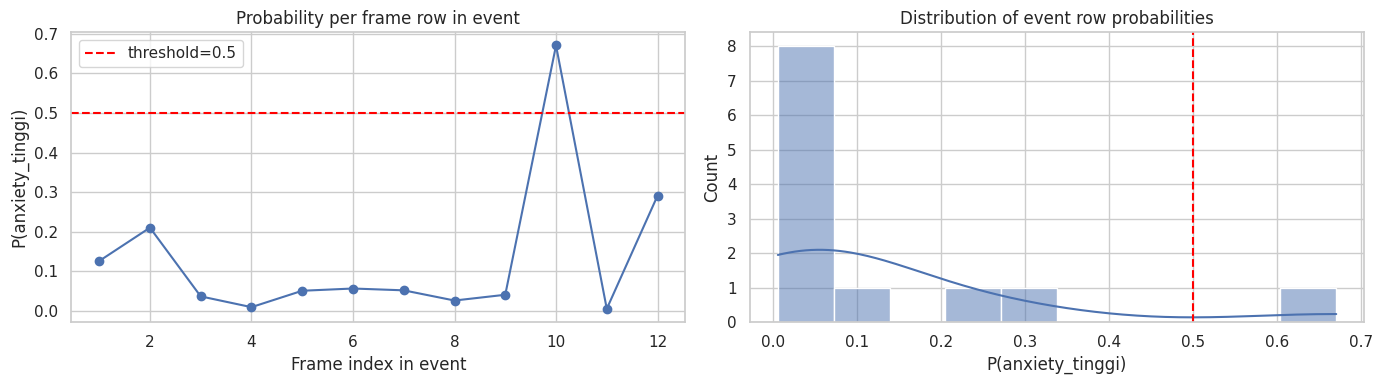

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(pred_df['frame_idx_in_event'], pred_df['prob_anxiety_tinggi'], marker='o')
axes[0].axhline(FINAL_THRESHOLD, color='red', linestyle='--', label=f'threshold={FINAL_THRESHOLD}')
axes[0].set_title('Probability per frame row in event')
axes[0].set_xlabel('Frame index in event')
axes[0].set_ylabel('P(anxiety_tinggi)')
axes[0].legend()

sns.histplot(pred_df['prob_anxiety_tinggi'], bins=10, kde=True, ax=axes[1])
axes[1].axvline(FINAL_THRESHOLD, color='red', linestyle='--')
axes[1].set_title('Distribution of event row probabilities')
axes[1].set_xlabel('P(anxiety_tinggi)')

plt.tight_layout()
plt.show()


In [6]:
event_result = infer_event_dir(EVENT_DIR)
display(pd.DataFrame([event_result]))


,event_dir,participant,true_group,n_feature_rows,aggregation,agg_prob_anxiety_tinggi,threshold,final_pred_label,final_pred_name,is_directionally_correct
0,output/apex/dataset/after/tidak/abdul_aziz_176...,abdul_aziz_1765187125263,tidak,12,top3_mean,0.390529,0.5,0,anxiety_rendah,True


## Batch sanity check

Gunakan 10 event `anxiety` dan 10 event `tidak` dari participant berbeda sebagai sanity-check kecil.


In [8]:
anxiety_events = pick_distinct_participant_events('anxiety', n=15)
tidak_events = pick_distinct_participant_events('tidak', n=15)
sample_events = anxiety_events + tidak_events

results = []
for event_dir in sample_events:
    try:
        results.append(infer_event_dir(event_dir))
    except Exception as e:
        meta = get_event_metadata(event_dir)
        results.append({
            'event_dir': str(event_dir.relative_to(ROOT)),
            'participant': meta['participant'],
            'true_group': meta['true_group'],
            'aggregation': EVENT_AGGREGATION_METHOD,
            'error': str(e),
        })

batch_df = pd.DataFrame(results)
display(batch_df)
if 'is_directionally_correct' in batch_df.columns:
    display(batch_df['is_directionally_correct'].value_counts(dropna=False).rename_axis('value').reset_index(name='count'))


KeyboardInterrupt: 

## Baseline confusion matrix (default `top3_mean`)


,precision,recall,f1-score,support
anxiety_rendah,0.857143,0.60,0.705882,10.00
anxiety_tinggi,0.692308,0.90,0.782609,10.00
accuracy,0.750000,0.75,0.750000,0.75
macro avg,0.774725,0.75,0.744246,20.00
weighted avg,0.774725,0.75,0.744246,20.00


,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,6,4
true_anxiety_tinggi,1,9


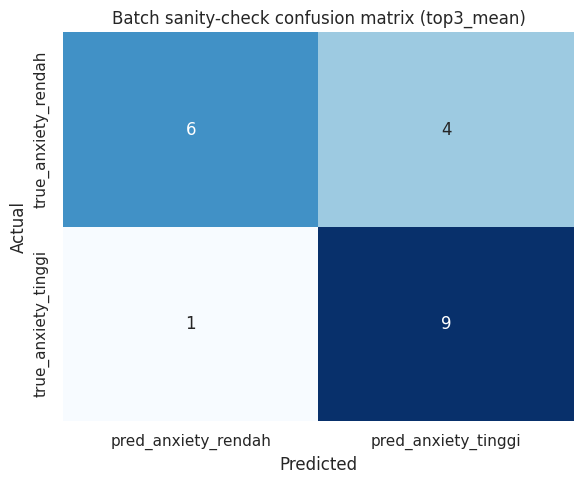

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

eval_df = batch_df.dropna(subset=['true_group', 'final_pred_name']).copy()
true_names = eval_df['true_group'].map({'anxiety': 'anxiety_tinggi', 'tidak': 'anxiety_rendah'})
pred_names = eval_df['final_pred_name']
labels = ['anxiety_rendah', 'anxiety_tinggi']

cm = confusion_matrix(true_names, pred_names, labels=labels)
report_df = pd.DataFrame(
    classification_report(
        true_names,
        pred_names,
        labels=labels,
        target_names=labels,
        output_dict=True,
    )
).T
display(report_df)

cm_df = pd.DataFrame(cm, index=[f'true_{x}' for x in labels], columns=[f'pred_{x}' for x in labels])
display(cm_df)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Batch sanity-check confusion matrix ({EVENT_AGGREGATION_METHOD})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()


## Aggregation comparison

Bandingkan beberapa cara agregasi event. Dari sini, fokus akhir dipersempit ke `top3_mean` dan `max`.


,event_dir,participant,true_group,n_feature_rows,aggregation,agg_prob_anxiety_tinggi,threshold,final_pred_label,final_pred_name,is_directionally_correct
0,output/apex/dataset/after/anxiety/aaisyah_nurs...,aaisyah_nursalsabiil_ni_patriarti_1765170495474,anxiety,26,top3_mean,0.918673,0.5,1,anxiety_tinggi,True
1,output/apex/dataset/after/anxiety/aaisyah_nurs...,aaisyah_nursalsabiil_ni_patriarti_1765170495474,anxiety,26,max,0.922180,0.5,1,anxiety_tinggi,True
2,output/apex/dataset/after/anxiety/aaisyah_nurs...,aaisyah_nursalsabiil_ni_patriarti_1765170495474,anxiety,26,mean,0.515913,0.5,1,anxiety_tinggi,True
3,output/apex/dataset/after/anxiety/aaisyah_nurs...,aaisyah_nursalsabiil_ni_patriarti_1765170495474,anxiety,26,median,0.554444,0.5,1,anxiety_tinggi,True
4,output/apex/dataset/after/anxiety/abdillah_agi...,abdillah_agil_arbiansyah_1765270077268,anxiety,20,top3_mean,0.799018,0.5,1,anxiety_tinggi,True
5,output/apex/dataset/after/anxiety/abdillah_agi...,abdillah_agil_arbiansyah_1765270077268,anxiety,20,max,0.883674,0.5,1,anxiety_tinggi,True
6,output/apex/dataset/after/anxiety/abdillah_agi...,abdillah_agil_arbiansyah_1765270077268,anxiety,20,mean,0.319470,0.5,0,anxiety_rendah,False
7,output/apex/dataset/after/anxiety/abdillah_agi...,abdillah_agil_arbiansyah_1765270077268,anxiety,20,median,0.207210,0.5,0,anxiety_rendah,False
8,output/apex/dataset/after/anxiety/adham_baskar...,adham_baskara_1765260172036,anxiety,18,top3_mean,0.903905,0.5,1,anxiety_tinggi,True
9,output/apex/dataset/after/anxiety/adham_baskar...,adham_baskara_1765260172036,anxiety,18,max,0.992952,0.5,1,anxiety_tinggi,True


,aggregation,n,n_correct,mean_prob,accuracy
3,top3_mean,20,15,0.656168,0.75
0,max,20,12,0.771840,0.60
1,mean,20,12,0.289835,0.60
2,median,20,12,0.232439,0.60


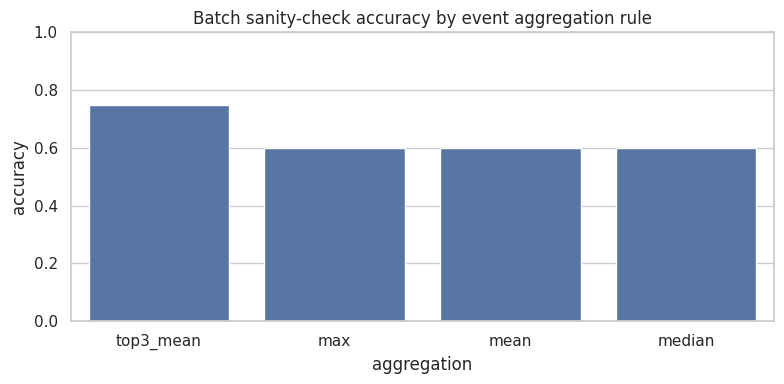

In [9]:
methods = ['top3_mean', 'max', 'mean', 'median']
compare_rows = []
for event_dir in sample_events:
    for method in methods:
        try:
            compare_rows.append(infer_event_dir(event_dir, method=method))
        except Exception as e:
            meta = get_event_metadata(event_dir)
            compare_rows.append({
                'event_dir': str(event_dir.relative_to(ROOT)),
                'participant': meta['participant'],
                'true_group': meta['true_group'],
                'aggregation': method,
                'error': str(e),
            })

compare_df = pd.DataFrame(compare_rows)
display(compare_df.head(20))

summary_df = (
    compare_df.dropna(subset=['is_directionally_correct'])
    .groupby('aggregation', as_index=False)
    .agg(
        n=('is_directionally_correct', 'size'),
        n_correct=('is_directionally_correct', 'sum'),
        mean_prob=('agg_prob_anxiety_tinggi', 'mean'),
    )
)
summary_df['accuracy'] = summary_df['n_correct'] / summary_df['n']
display(summary_df.sort_values(['accuracy', 'aggregation'], ascending=[False, True]))

plt.figure(figsize=(8, 4))
sns.barplot(data=summary_df, x='aggregation', y='accuracy', order=methods)
plt.ylim(0, 1)
plt.title('Batch sanity-check accuracy by event aggregation rule')
plt.tight_layout()
plt.show()


## Threshold sweep for `top3_mean`

Cari threshold event yang masuk akal untuk rule `top3_mean >= t`.


,threshold,tp,tn,fp,fn,sensitivity_anxiety,specificity_tidak,accuracy,balanced_accuracy
8,0.70,8,8,2,2,0.8,0.8,0.80,0.80
9,0.75,8,8,2,2,0.8,0.8,0.80,0.80
11,0.85,6,10,0,4,0.6,1.0,0.80,0.80
12,0.90,6,10,0,4,0.6,1.0,0.80,0.80
4,0.50,9,6,4,1,0.9,0.6,0.75,0.75
5,0.55,9,6,4,1,0.9,0.6,0.75,0.75
6,0.60,8,7,3,2,0.8,0.7,0.75,0.75
7,0.65,8,7,3,2,0.8,0.7,0.75,0.75
2,0.40,10,4,6,0,1.0,0.4,0.70,0.70
10,0.80,6,8,2,4,0.6,0.8,0.70,0.70


,threshold,tp,tn,fp,fn,sensitivity_anxiety,specificity_tidak,accuracy,balanced_accuracy
8,0.70,8,8,2,2,0.8,0.8,0.80,0.80
9,0.75,8,8,2,2,0.8,0.8,0.80,0.80
11,0.85,6,10,0,4,0.6,1.0,0.80,0.80
12,0.90,6,10,0,4,0.6,1.0,0.80,0.80
4,0.50,9,6,4,1,0.9,0.6,0.75,0.75


best top3_mean threshold: 0.7
balanced accuracy: 0.8
accuracy: 0.8


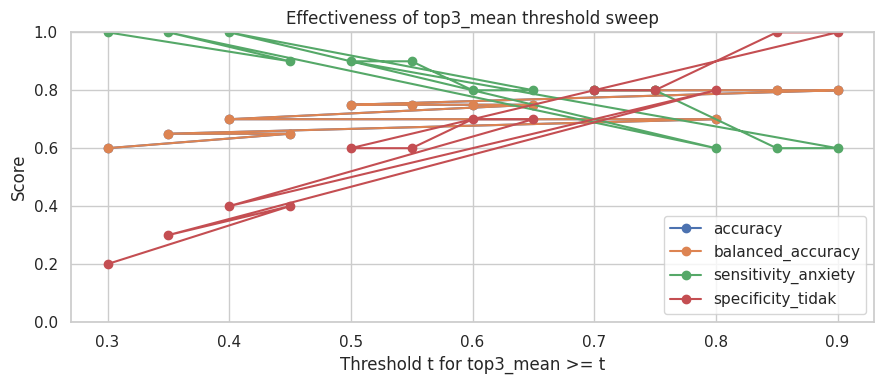

In [10]:
top3_eval_df = compare_df[compare_df['aggregation'] == 'top3_mean'].dropna(subset=['true_group', 'agg_prob_anxiety_tinggi']).copy()
top3_eval_df['true_label'] = (top3_eval_df['true_group'] == 'anxiety').astype(int)
thresholds = np.round(np.arange(0.30, 0.91, 0.05), 2)
rows = []
for t in thresholds:
    pred = (top3_eval_df['agg_prob_anxiety_tinggi'] >= t).astype(int)
    tp = int(((top3_eval_df['true_label'] == 1) & (pred == 1)).sum())
    tn = int(((top3_eval_df['true_label'] == 0) & (pred == 0)).sum())
    fp = int(((top3_eval_df['true_label'] == 0) & (pred == 1)).sum())
    fn = int(((top3_eval_df['true_label'] == 1) & (pred == 0)).sum())
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    accuracy = (tp + tn) / len(top3_eval_df)
    balanced_accuracy = np.nanmean([sensitivity, specificity])
    rows.append({
        'threshold': t,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'sensitivity_anxiety': sensitivity,
        'specificity_tidak': specificity,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_accuracy,
    })

top3_threshold_df = pd.DataFrame(rows).sort_values(['balanced_accuracy', 'accuracy', 'threshold'], ascending=[False, False, True])
display(top3_threshold_df)
display(top3_threshold_df.head(5))

best_top3 = top3_threshold_df.iloc[0]
print('best top3_mean threshold:', best_top3['threshold'])
print('balanced accuracy:', round(float(best_top3['balanced_accuracy']), 4))
print('accuracy:', round(float(best_top3['accuracy']), 4))

plt.figure(figsize=(9, 4))
plt.plot(top3_threshold_df['threshold'], top3_threshold_df['accuracy'], marker='o', label='accuracy')
plt.plot(top3_threshold_df['threshold'], top3_threshold_df['balanced_accuracy'], marker='o', label='balanced_accuracy')
plt.plot(top3_threshold_df['threshold'], top3_threshold_df['sensitivity_anxiety'], marker='o', label='sensitivity_anxiety')
plt.plot(top3_threshold_df['threshold'], top3_threshold_df['specificity_tidak'], marker='o', label='specificity_tidak')
plt.xlabel('Threshold t for top3_mean >= t')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Effectiveness of top3_mean threshold sweep')
plt.legend()
plt.tight_layout()
plt.show()


## Threshold sweep for `max`

Cari threshold event yang masuk akal untuk rule `max >= t`.


,threshold,tp,tn,fp,fn,sensitivity_anxiety,specificity_tidak,accuracy,balanced_accuracy
12,0.90,7,10,0,3,0.7,1.0,0.85,0.85
11,0.85,8,8,2,2,0.8,0.8,0.80,0.80
13,0.95,5,10,0,5,0.5,1.0,0.75,0.75
9,0.75,9,5,5,1,0.9,0.5,0.70,0.70
10,0.80,8,6,4,2,0.8,0.6,0.70,0.70
7,0.65,9,4,6,1,0.9,0.4,0.65,0.65
8,0.70,9,4,6,1,0.9,0.4,0.65,0.65
0,0.30,10,2,8,0,1.0,0.2,0.60,0.60
1,0.35,10,2,8,0,1.0,0.2,0.60,0.60
2,0.40,10,2,8,0,1.0,0.2,0.60,0.60


,threshold,tp,tn,fp,fn,sensitivity_anxiety,specificity_tidak,accuracy,balanced_accuracy
12,0.90,7,10,0,3,0.7,1.0,0.85,0.85
11,0.85,8,8,2,2,0.8,0.8,0.80,0.80
13,0.95,5,10,0,5,0.5,1.0,0.75,0.75
9,0.75,9,5,5,1,0.9,0.5,0.70,0.70
10,0.80,8,6,4,2,0.8,0.6,0.70,0.70


best max threshold: 0.9
balanced accuracy: 0.85
accuracy: 0.85


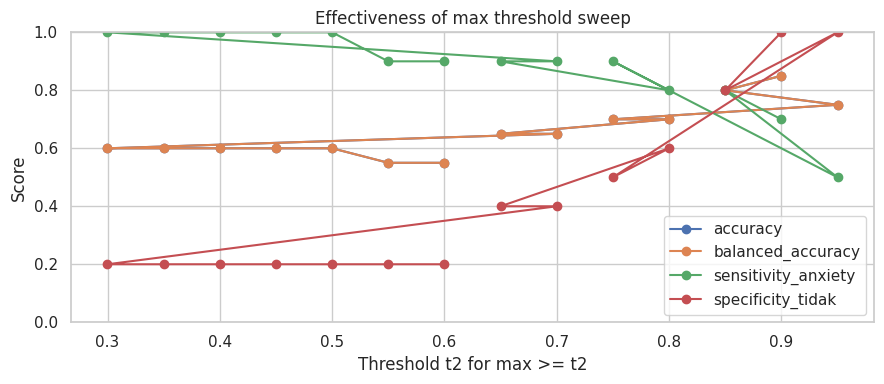

In [11]:
max_eval_df = compare_df[compare_df['aggregation'] == 'max'].dropna(subset=['true_group', 'agg_prob_anxiety_tinggi']).copy()
max_eval_df['true_label'] = (max_eval_df['true_group'] == 'anxiety').astype(int)
thresholds = np.round(np.arange(0.30, 0.991, 0.05), 2)
rows = []
for t2 in thresholds:
    pred = (max_eval_df['agg_prob_anxiety_tinggi'] >= t2).astype(int)
    tp = int(((max_eval_df['true_label'] == 1) & (pred == 1)).sum())
    tn = int(((max_eval_df['true_label'] == 0) & (pred == 0)).sum())
    fp = int(((max_eval_df['true_label'] == 0) & (pred == 1)).sum())
    fn = int(((max_eval_df['true_label'] == 1) & (pred == 0)).sum())
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    accuracy = (tp + tn) / len(max_eval_df)
    balanced_accuracy = np.nanmean([sensitivity, specificity])
    rows.append({
        'threshold': t2,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'sensitivity_anxiety': sensitivity,
        'specificity_tidak': specificity,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_accuracy,
    })

max_threshold_df = pd.DataFrame(rows).sort_values(['balanced_accuracy', 'accuracy', 'threshold'], ascending=[False, False, True])
display(max_threshold_df)
display(max_threshold_df.head(5))

best_max = max_threshold_df.iloc[0]
print('best max threshold:', best_max['threshold'])
print('balanced accuracy:', round(float(best_max['balanced_accuracy']), 4))
print('accuracy:', round(float(best_max['accuracy']), 4))

plt.figure(figsize=(9, 4))
plt.plot(max_threshold_df['threshold'], max_threshold_df['accuracy'], marker='o', label='accuracy')
plt.plot(max_threshold_df['threshold'], max_threshold_df['balanced_accuracy'], marker='o', label='balanced_accuracy')
plt.plot(max_threshold_df['threshold'], max_threshold_df['sensitivity_anxiety'], marker='o', label='sensitivity_anxiety')
plt.plot(max_threshold_df['threshold'], max_threshold_df['specificity_tidak'], marker='o', label='specificity_tidak')
plt.xlabel('Threshold t2 for max >= t2')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.title('Effectiveness of max threshold sweep')
plt.legend()
plt.tight_layout()
plt.show()


## Final candidate rules

Pertahankan dua kandidat akhir berikut untuk dinilai lebih lanjut:
- `top3_mean >= 0.70`
- `max >= 0.90`


In [12]:
top3_scores = compare_df[compare_df['aggregation'] == 'top3_mean'][['event_dir', 'true_group', 'participant', 'agg_prob_anxiety_tinggi']].rename(columns={'agg_prob_anxiety_tinggi': 'top3_mean_score'})
max_scores = compare_df[compare_df['aggregation'] == 'max'][['event_dir', 'agg_prob_anxiety_tinggi']].rename(columns={'agg_prob_anxiety_tinggi': 'max_score'})
rule_eval_df = top3_scores.merge(max_scores, on='event_dir', how='inner')
rule_eval_df['true_label'] = (rule_eval_df['true_group'] == 'anxiety').astype(int)
rule_eval_df['pred_top3_070'] = (rule_eval_df['top3_mean_score'] >= 0.70).astype(int)
rule_eval_df['pred_max_090'] = (rule_eval_df['max_score'] >= 0.90).astype(int)

def summarize_rule(df: pd.DataFrame, pred_col: str, rule_name: str) -> dict:
    pred = df[pred_col]
    true = df['true_label']
    tp = int(((true == 1) & (pred == 1)).sum())
    tn = int(((true == 0) & (pred == 0)).sum())
    fp = int(((true == 0) & (pred == 1)).sum())
    fn = int(((true == 1) & (pred == 0)).sum())
    sensitivity = tp / (tp + fn) if (tp + fn) else np.nan
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    accuracy = (tp + tn) / len(df)
    balanced_accuracy = np.nanmean([sensitivity, specificity])
    return {
        'rule': rule_name,
        'tp': tp,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'sensitivity_anxiety': sensitivity,
        'specificity_tidak': specificity,
        'accuracy': accuracy,
        'balanced_accuracy': balanced_accuracy,
    }

final_rule_summary_df = pd.DataFrame([
    summarize_rule(rule_eval_df, 'pred_top3_070', 'top3_mean >= 0.70'),
    summarize_rule(rule_eval_df, 'pred_max_090', 'max >= 0.90'),
])
display(final_rule_summary_df)

display(rule_eval_df[['event_dir', 'participant', 'true_group', 'top3_mean_score', 'max_score', 'pred_top3_070', 'pred_max_090']])


,rule,tp,tn,fp,fn,sensitivity_anxiety,specificity_tidak,accuracy,balanced_accuracy
0,top3_mean >= 0.70,8,8,2,2,0.8,0.8,0.80,0.80
1,max >= 0.90,7,10,0,3,0.7,1.0,0.85,0.85


,event_dir,participant,true_group,top3_mean_score,max_score,pred_top3_070,pred_max_090
0,output/apex/dataset/after/anxiety/aaisyah_nurs...,aaisyah_nursalsabiil_ni_patriarti_1765170495474,anxiety,0.918673,0.922180,1,1
1,output/apex/dataset/after/anxiety/abdillah_agi...,abdillah_agil_arbiansyah_1765270077268,anxiety,0.799018,0.883674,1,0
2,output/apex/dataset/after/anxiety/adham_baskar...,adham_baskara_1765260172036,anxiety,0.903905,0.992952,1,1
3,output/apex/dataset/after/anxiety/ananda_satri...,ananda_satria_putra_nugraha_1765170698589,anxiety,0.975359,0.991509,1,1
4,output/apex/dataset/after/anxiety/danendra_adh...,danendra_adhipramana_1765187441060,anxiety,0.447363,0.544080,0,0
5,output/apex/dataset/after/anxiety/dewita_anggr...,dewita_anggraini_1765270758137,anxiety,0.900100,0.968425,1,1
6,output/apex/dataset/after/anxiety/dika_arie_ar...,dika_arie_arrifky_1765267715331,anxiety,0.961346,0.970689,1,1
7,output/apex/dataset/after/anxiety/duta_kurnia_...,duta_kurnia_ardhani_1765255548331,anxiety,0.968127,0.990896,1,1
8,output/apex/dataset/after/anxiety/esa_pratama_...,esa_pratama_putri_1765175263386,anxiety,0.575093,0.755610,0,0
9,output/apex/dataset/after/anxiety/fabian_anand...,fabian_ananda_merdana_1765260042452,anxiety,0.799524,0.926124,1,1


## Confusion matrices for final candidate rules



top3_mean >= 0.70


,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,8,2
true_anxiety_tinggi,2,8



max >= 0.90


,pred_anxiety_rendah,pred_anxiety_tinggi
true_anxiety_rendah,10,0
true_anxiety_tinggi,3,7


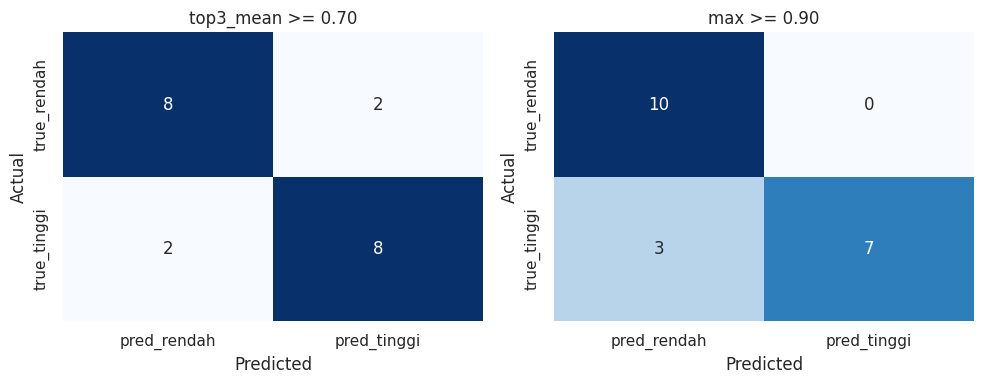

In [13]:
candidate_cm_df = rule_eval_df.copy()
candidate_cm_df['true_name'] = candidate_cm_df['true_group'].map({'anxiety': 'anxiety_tinggi', 'tidak': 'anxiety_rendah'})
rule_to_col = {
    'top3_mean >= 0.70': 'pred_top3_070',
    'max >= 0.90': 'pred_max_090',
}

for rule_name, pred_col in rule_to_col.items():
    pred_name = candidate_cm_df[pred_col].map({1: 'anxiety_tinggi', 0: 'anxiety_rendah'})
    cm = confusion_matrix(
        candidate_cm_df['true_name'],
        pred_name,
        labels=['anxiety_rendah', 'anxiety_tinggi'],
    )
    cm_df = pd.DataFrame(
        cm,
        index=['true_anxiety_rendah', 'true_anxiety_tinggi'],
        columns=['pred_anxiety_rendah', 'pred_anxiety_tinggi'],
    )
    print(f'\n{rule_name}')
    display(cm_df)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (rule_name, pred_col) in zip(axes, rule_to_col.items()):
    pred_name = candidate_cm_df[pred_col].map({1: 'anxiety_tinggi', 0: 'anxiety_rendah'})
    cm = confusion_matrix(
        candidate_cm_df['true_name'],
        pred_name,
        labels=['anxiety_rendah', 'anxiety_tinggi'],
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['pred_rendah', 'pred_tinggi'],
        yticklabels=['true_rendah', 'true_tinggi'],
        ax=ax,
    )
    ax.set_title(rule_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


In [ ]:
# Input folder name/path here. Bisa nama folder saja, path relatif dari ROOT, atau path absolut.
FOLDER_QUERY = 'answer_3_ce8ef7e8-63e6-46c1-a510-1b8269c27ce7_sec'
SEARCH_ROOT = ROOT / 'output' / 'apex' / 'dataset'

def resolve_target_folder(folder_query: str, search_root: Path = SEARCH_ROOT) -> Path:
    candidate = Path(folder_query).expanduser()
    if candidate.is_absolute() and candidate.exists():
        return candidate

    relative_candidate = (ROOT / folder_query).resolve()
    if relative_candidate.exists():
        return relative_candidate

    matches = []
    for p in search_root.rglob('*'):
        if not p.is_dir():
            continue
        if p.name == folder_query or folder_query in str(p.relative_to(search_root)):
            matches.append(p)

    if not matches:
        raise FileNotFoundError(f'Folder not found: {folder_query}')
    if len(matches) > 1:
        match_list = '\n'.join(str(p.relative_to(ROOT)) for p in matches[:10])
        raise ValueError(f'Multiple folders matched for {folder_query}:\n{match_list}')
    return matches[0]

def collect_event_dirs(target_folder: Path) -> list[Path]:
    if target_folder.name.startswith('event_'):
        return [target_folder]
    event_dirs = sorted([p for p in target_folder.rglob('event_*') if p.is_dir()])
    if not event_dirs:
        raise ValueError(f'No event_* folder found inside: {target_folder}')
    return event_dirs

target_folder = resolve_target_folder(FOLDER_QUERY)
target_event_dirs = collect_event_dirs(target_folder)

folder_rows = []
for event_dir in target_event_dirs:
    top3_result = infer_event_dir(event_dir, method='top3_mean')
    max_result = infer_event_dir(event_dir, method='max')
    folder_rows.append({
        'event_dir': top3_result['event_dir'],
        'participant': top3_result['participant'],
        'true_group': top3_result['true_group'],
        'n_feature_rows': top3_result['n_feature_rows'],
        'top3_mean_score': top3_result['agg_prob_anxiety_tinggi'],
        'max_score': max_result['agg_prob_anxiety_tinggi'],
        'pred_top3_070': 'anxiety_tinggi' if top3_result['agg_prob_anxiety_tinggi'] >= 0.70 else 'anxiety_rendah',
        'pred_max_090': 'anxiety_tinggi' if max_result['agg_prob_anxiety_tinggi'] >= 0.90 else 'anxiety_rendah',
    })

folder_pred_df = pd.DataFrame(folder_rows)
display(folder_pred_df)

folder_summary = pd.DataFrame([{
    'target_folder': str(target_folder.relative_to(ROOT)) if target_folder.is_relative_to(ROOT) else str(target_folder),
    'n_events': len(folder_pred_df),
    'mean_top3_mean_score': folder_pred_df['top3_mean_score'].mean(),
    'mean_max_score': folder_pred_df['max_score'].mean(),
    'n_top3_high': int((folder_pred_df['pred_top3_070'] == 'anxiety_tinggi').sum()),
    'n_top3_low': int((folder_pred_df['pred_top3_070'] == 'anxiety_rendah').sum()),
    'n_max_high': int((folder_pred_df['pred_max_090'] == 'anxiety_tinggi').sum()),
    'n_max_low': int((folder_pred_df['pred_max_090'] == 'anxiety_rendah').sum()),
    'final_folder_pred_top3_070': 'anxiety_tinggi' if (folder_pred_df['pred_top3_070'] == 'anxiety_tinggi').sum() >= (len(folder_pred_df) / 2) else 'anxiety_rendah',
    'final_folder_pred_max_090': 'anxiety_tinggi' if (folder_pred_df['pred_max_090'] == 'anxiety_tinggi').sum() >= (len(folder_pred_df) / 2) else 'anxiety_rendah',
}])
display(folder_summary)
